In [1]:
!pip install numpy


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pydicom
import numpy as np

ds = pydicom.dcmread(r"../PID Removal from February 20 2026/1.2.840.113564.54.2026020613015627.948.dcm")

pixels = ds.pixel_array.astype(np.float32)

print("Shape:", pixels.shape)
print("Min:", pixels.min())
print("Max:", pixels.max())
print("Mean:", pixels.mean())

print("Window Center:", getattr(ds, "WindowCenter", None))
print("Window Width:", getattr(ds, "WindowWidth", None))
print("Bits Stored:", ds.BitsStored)
print("Pixel Representation:", ds.PixelRepresentation)

Shape: (2800, 2304)
Min: 29.0
Max: 2855.0
Mean: 1637.4949
Window Center: 1907
Window Width: 3657
Bits Stored: 12
Pixel Representation: 0


In [6]:
print(ds.Modality)
print(ds.PhotometricInterpretation)
print(getattr(ds, "PresentationLUTShape", None))
print(getattr(ds, "VOILUTFunction", None))
print(getattr(ds, "WindowCenterWidthExplanation", None))

DX
MONOCHROME1
None
None
None


In [10]:
!pip install opencv-python

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/44.0 MB 2.4 MB/s eta 0:00:19
    --------------------------------------- 1.0/44.0 MB 2.3 MB/s eta 0:00:19
   - -------------------------------------- 1.3/44.0 MB 2.2 MB/s eta 0:00:20
   - -------------------------------------- 1.6/44.0 MB 2.0 MB/s eta 0:00:21
   - -------------------------------------- 2.1/44.0 MB 2.1 MB/s eta 0:00:21
   -- ------------------------------------- 2.4/44.0 MB 1.8 MB/s eta 0:00:23
   -- ------------------------------------- 2.6/44.0 MB 1.7 MB/s eta 0:00:24
   -- ------------------------------------- 2.9/44.0 MB 1.6 MB/s eta 0:00:26
   -- ------------------------------------- 2.9/44.0 MB 1.6 MB/s eta 0:00:26
   -- ------------------------------------- 3.1/44.0 MB 1.5 MB/s eta 0:00:27
   --- ------------------------------------ 3.4/44.0 MB 1.4 MB/s eta 0:00:30
   --- ------


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
!pip install matplotlib

  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 837.5 kB/s eta 0:00:10
   --- ------------------------------------ 0.8/8.2 MB 931.2 kB/s eta 0:00:08
   ------ --------------------------------- 1.3/8.2 MB 1.2 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.2 MB 1.3 MB/s eta 0:00:05
   ---------- ----------------------------- 2.1/8.2 MB 1.5 MB/s eta 0:00:05
   ------------ --------------------------- 2.6/8.2 MB 1.6 MB/s eta 0:00:04
   ------------ --------------------------- 2.6/8.2 MB 1.6 MB/s eta 0:00:04
   -------------- ------------------------- 2.9/8.2 


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


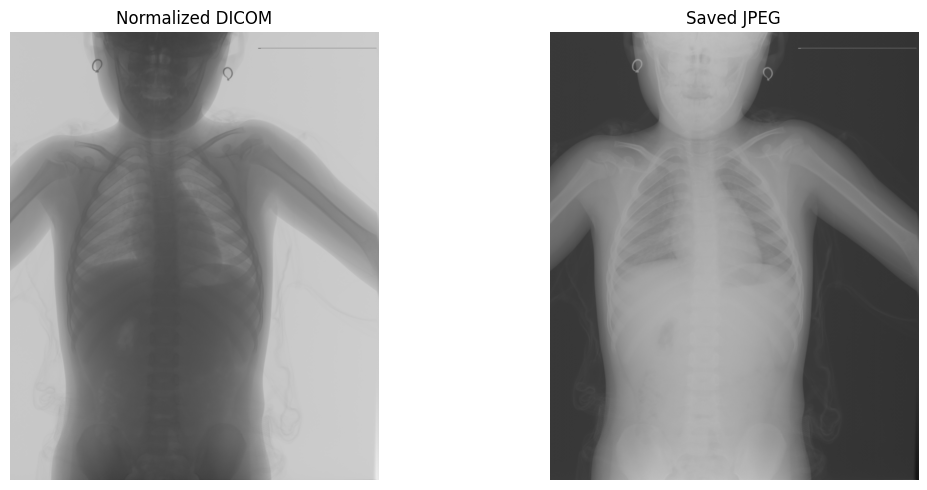

In [16]:
import pydicom
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Path to the DICOM file
dcm_path = r"../PID Removal from February 20 2026/1.2.840.113564.54.2026020613015627.948.dcm"

# Output JPEG path
jpg_path = r"../Chest X-rays Jpeg/output.jpg"

# Read DICOM
ds = pydicom.dcmread(dcm_path)

# Get pixel array
image = ds.pixel_array.astype(np.float32)

# Apply rescale slope/intercept if present
slope = float(ds.get("RescaleSlope", 1))
intercept = float(ds.get("RescaleIntercept", 0))
image = image * slope + intercept

# Normalize to 0-255 (no windowing)
image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)
image = image.astype(np.uint8)

# Display
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Normalized DICOM")
plt.axis("off")

if ds.PhotometricInterpretation == "MONOCHROME1":
    image = 255 - image
    
# Save as JPEG
cv2.imwrite(jpg_path, image)

# Read the saved JPEG
jpg = cv2.imread(jpg_path, cv2.IMREAD_GRAYSCALE)

plt.subplot(1, 2, 2)
plt.imshow(jpg, cmap="gray")
plt.title("Saved JPEG")
plt.axis("off")

plt.tight_layout()
plt.show()

In [1]:
import os
print(os.environ['Path'])

d:\ai-based-medical-imaging\.venv\Scripts;D:\ai-based-medical-imaging\.venv\Scripts;C:\WINDOWS\system32;C:\WINDOWS;C:\WINDOWS\System32\Wbem;C:\WINDOWS\System32\WindowsPowerShell\v1.0\;C:\WINDOWS\System32\OpenSSH\;C:\Program Files\NVIDIA Corporation\NVIDIA App\NvDLISR;C:\Program Files (x86)\NVIDIA Corporation\PhysX\Common;C:\Program Files\Docker\Docker\resources\bin;C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\Scripts;C:\Program Files\Git\bin;C:\Program Files\Tesseract-OCR;C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps;C:\Users\Lenovo\AppData\Local\Programs\Microsoft VS Code\bin;C:\Users\Lenovo\AppData\Local\Programs\Ollama;


Using CPU. Note: This module is much faster with a GPU.


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

d:\ai-based-medical-imaging\.venv\lib\site-packages\torch\ao\nn\quantized\dynamic\modules\rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\quantized\Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(
d:\ai-based-medical-imaging\.venv\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Detected: 'R' (1.00)


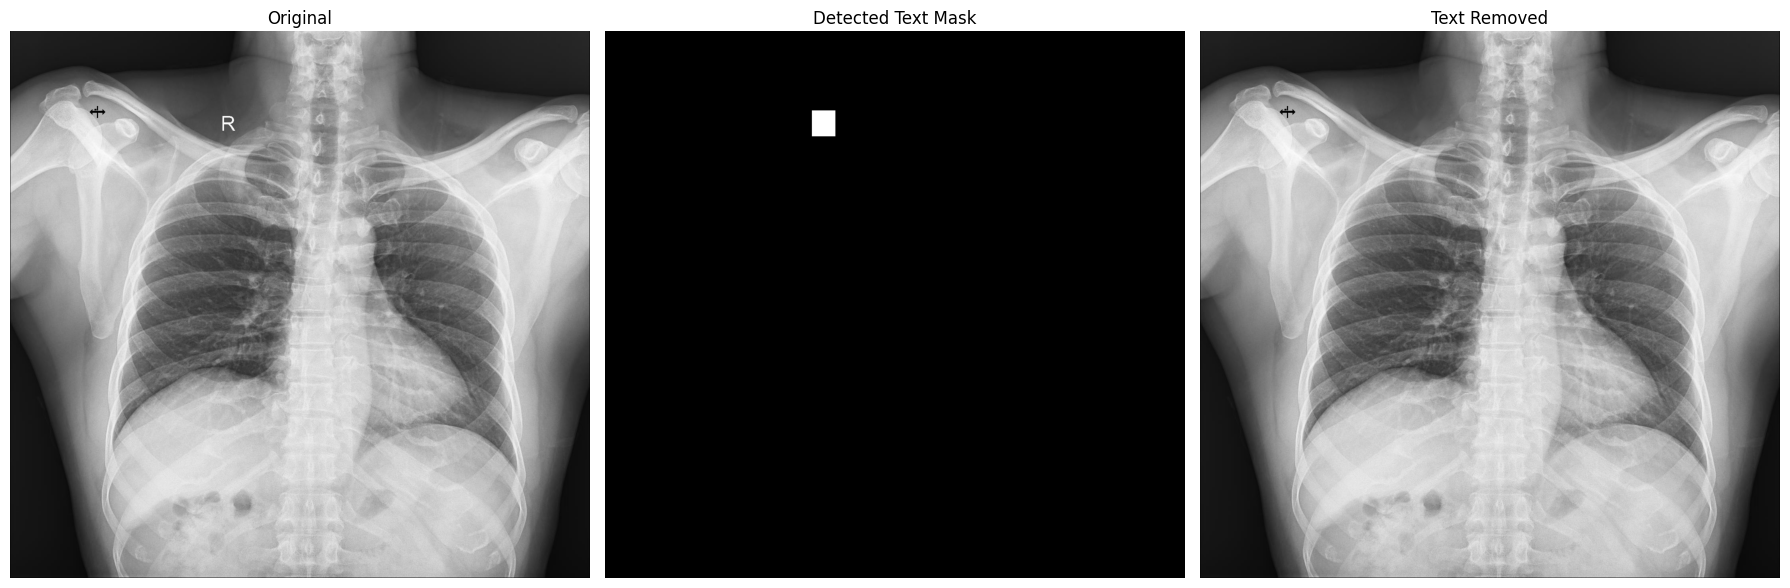

True

In [1]:
import cv2
import easyocr
import numpy as np
import matplotlib.pyplot as plt

# Load image
image_path = r"D:\ai-based-medical-imaging\Chest X-rays (Dhulikhel Hospital) by Amir June 5 2026\CD1\JPG00316.jpg"
image = cv2.imread(image_path)
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Initialize EasyOCR
reader = easyocr.Reader(['en'], gpu=False)

# Detect text
results = reader.readtext(rgb)

# Create mask
mask = np.zeros(image.shape[:2], dtype=np.uint8)

padding = 8

for (bbox, text, confidence) in results:

    # Ignore weak detections
    if confidence < 0.20:
        continue

    # Convert polygon to rectangle
    pts = np.array(bbox).astype(int)

    x_min = max(0, pts[:, 0].min() - padding)
    y_min = max(0, pts[:, 1].min() - padding)
    x_max = min(image.shape[1], pts[:, 0].max() + padding)
    y_max = min(image.shape[0], pts[:, 1].max() + padding)

    # Draw mask
    cv2.rectangle(mask, (x_min, y_min), (x_max, y_max), 255, -1)

    print(f"Detected: '{text}' ({confidence:.2f})")

# Remove text
result = cv2.inpaint(image, mask, 7, cv2.INPAINT_TELEA)

# Display
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Detected Text Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Text Removed")
plt.axis("off")

plt.tight_layout()
plt.show()

cv2.imwrite("xray_text_removed.jpg", result)